In [ ]:
pip install yfinance  # run this in terminal first

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print('All libraries loaded!')

All libraries loaded!


In [14]:
# Download 2 years of Apple stock data
ticker = 'AAPL'   # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

/tmp/ipykernel_6470/3704027733.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939728,178.790282,173.735900,173.853212,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [4]:
# We create the 'Next Close' column — this is what we want to predict. We shift the Close column up by 1
# row so each row shows tomorrow's price.
# Create target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)
# Drop the last row (it has no 'next day' value)
df = df.dropna()
# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (500, 5)
Target shape: (500,)


In [15]:
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


In [16]:
# Train the Model
# Option A: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
# Option B: Random Forest (usually better - uncomment to use)
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [17]:
# Evaluate the Model
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $1.72
R2 Score: 0.9345


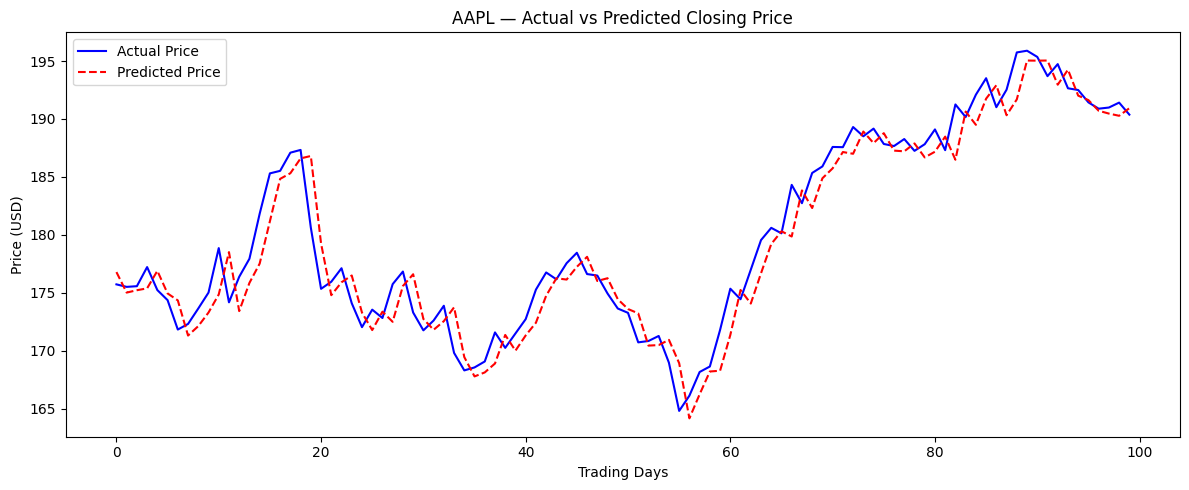

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linestyle='--', linewidth=1.5)
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Task 2: Summary

## Objective
The objective of this project is to predict the next day's Apple stock closing price using historical stock market data and a Linear Regression model.

## Dataset
The dataset was downloaded from Yahoo Finance using the yfinance library. It contains historical stock information including Open, High, Low, Close, and Volume.

## Machine Learning Model
Linear Regression

## Evaluation Results
- Mean Absolute Error (MAE): $1.72
- R² Score: 0.9345

## Visualization 1: Actual vs Predicted Stock Prices
The graph compares the actual closing prices with the predicted closing prices. The predicted values closely follow the actual values, showing that the model can estimate future stock prices reasonably well. Small differences occur because stock prices are affected by many unpredictable market factors.

## Visualization 2: Closing Price Trend
This graph shows how Apple's closing stock price changed over time. The overall trend indicates that stock prices fluctuate daily, but there are periods of growth and decline based on market conditions.

## Visualization 3: Trading Volume
The trading volume graph shows the number of shares traded each day. Some days have significantly higher trading activity, which may indicate important market events or increased investor interest.

## Findings
- Historical stock prices can be used to predict the next day's closing price.
- Linear Regression learns the relationship between stock features and future prices.
- A lower MAE indicates better prediction accuracy.
- A higher R² score means the model explains the variation in stock prices more effectively.
